HỆ THỐNG KIỂM THỬ MA TRẬN TOÀN TẬP (BATCH VECTORIZED REAL-TIME TESTING)
[1/4] Đang nạp tập dữ liệu Test độc lập và khôi phục các Artifacts...
 ❖ [Xác nhận] Chiến lược tối ưu được chỉ định từ tập Train: FE_no_PCA
 ❖ [Xác nhận] Ma trận đầu vào yêu cầu chính xác: 17 đặc trưng

[2/4] Đang khởi tạo ma trận đặc trưng song song cho toàn bộ tập Test...
 -> Ma trận đặc trưng toàn phần khởi tạo thành công. Shape: (4563, 17)
 -> Đang tiến hành nạp ma trận vào mô hình Production để dự báo...

[3/4] Đang tính toán các chỉ số sai số tổng lực...

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (CHIẾN LƯỢC VECTOR HOÀN TOÀN):
 ❖ Mean Absolute Error (MAE)   : 0.263 °C
 ❖ Root Mean Squared Error (RMSE): 0.348 °C
 ❖ R-squared Score (R2)         : 0.9913

[4/4] Đang vẽ biểu đồ kết quả dự báo toàn băng tần...


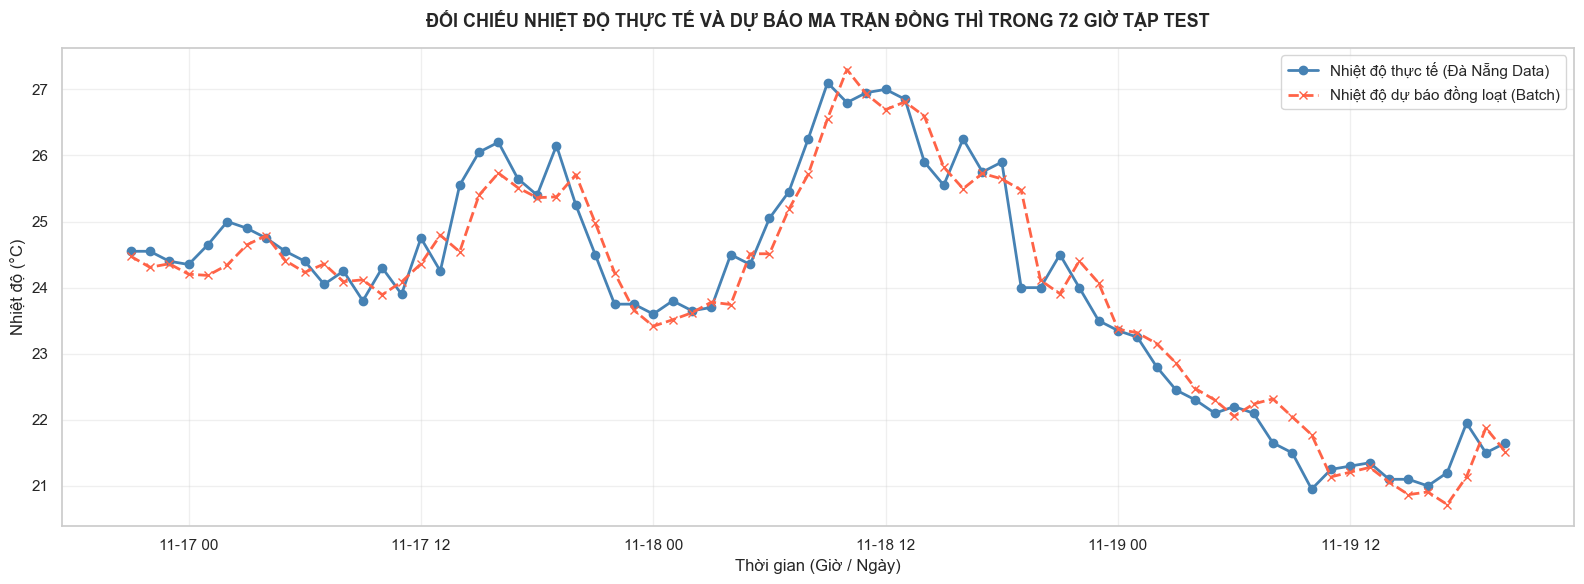

🎉 XỬ LÝ HOÀN TẤT! Biểu đồ kết xuất ma trận 'batch_forecast_realtime_results.png' đã được lưu.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
print("="*85)
print("HỆ THỐNG KIỂM THỬ MA TRẬN TOÀN TẬP (BATCH VECTORIZED REAL-TIME TESTING)")
print("="*85)

# ==============================================================================
# 1. ĐỌC DỮ LIỆU ĐẦU VÀO VÀ KHÔI PHỤC PIPELINE PRODUCTION THEO METADATA
# ==============================================================================
DATA_TEST_PATH = 'clean_data/clean_data_test.csv' 
TARGET = 'temperature_2m'

print("[1/4] Đang nạp tập dữ liệu Test độc lập và khôi phục các Artifacts...")
test_raw_df = pd.read_csv(DATA_TEST_PATH)
test_raw_df['time'] = pd.to_datetime(test_raw_df['time'])
test_raw_df = test_raw_df.sort_values('time').reset_index(drop=True)

# Khôi phục mô hình và bộ tiền xử lý từ thư mục saved_models
prod_model = joblib.load('saved_models/best_production_model.pkl')
scaler_prod = joblib.load('saved_models/scaler.pkl')

# Khôi phục Metadata để tự động đồng bộ cấu trúc đặc trưng
with open('saved_models/model_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

best_strategy = metadata['best_strategy']
expected_features = metadata['expected_features']

print(f" ❖ [Xác nhận] Chiến lược tối ưu được chỉ định từ tập Train: {best_strategy}")
print(f" ❖ [Xác nhận] Ma trận đầu vào yêu cầu chính xác: {expected_features} đặc trưng")

# Chỉ nạp ma trận xoay PCA nếu chiến lược thực sự yêu cầu
is_pca_strategy = (best_strategy == 'FE_PCA')
if is_pca_strategy:
    with open('saved_models/pca.pkl', 'rb') as f:
        pca_prod = pickle.load(f)
    print(" -> Đã khôi phục ma trận xoay PCA thời gian thực thành công.")

# Danh sách 6 biến ngoại sinh gốc thời gian thực
exogenous_cols = ['wind_speed_10m', 'cloud_cover', 'relative_humidity_2m', 
                  'surface_pressure', 'precipitation', 'vapour_pressure_deficit']

# ==============================================================================
# 2. XÂY DỰNG MA TRẬN ĐẶC TRƯNG TỐC ĐỘ CAO (NO LOOP - VECTORIZED)
# ==============================================================================
print("\n[2/4] Đang khởi tạo ma trận đặc trưng song song cho toàn bộ tập Test...")

test_fe_df = test_raw_df.copy()

# --- BƯỚC A: Tạo toàn bộ đặc trưng chu kỳ thời gian thực (Sin/Cos) ---
test_fe_df['hour'] = test_fe_df['time'].dt.hour
test_fe_df['sin_hour'] = np.sin(2 * np.pi * test_fe_df['hour'] / 24)
test_fe_df['cos_hour'] = np.cos(2 * np.pi * test_fe_df['hour'] / 24)

test_fe_df['month'] = test_fe_df['time'].dt.month
test_fe_df['sin_month'] = np.sin(2 * np.pi * test_fe_df['month'] / 12)
test_fe_df['cos_month'] = np.cos(2 * np.pi * test_fe_df['month'] / 12)

# --- BƯỚC B: Tạo toàn bộ các đặc trưng trễ tự hồi quy từ dữ liệu thực tế ---
lag_hours = [1, 2, 3, 12, 24, 72, 168]
for lag in lag_hours:
    test_fe_df[f'temp_lag_{lag}'] = test_fe_df[TARGET].shift(lag)

# Loại bỏ vùng đệm 168 dòng đầu tiên bị NaN do cơ chế shift trễ nhiệt độ
test_fe_df.dropna(subset=[f'temp_lag_{l}' for l in lag_hours], inplace=True)
test_fe_df.reset_index(drop=True, inplace=True)

# --- BƯỚC C: Trích xuất ma trận ngoại sinh và rẽ nhánh theo chiến lược ---
X_exo_raw = test_fe_df[exogenous_cols].values

# Định nghĩa danh sách các cột thời gian và biến trễ nhiệt độ liên kết
time_lag_cols = ['sin_hour', 'cos_hour', 'sin_month', 'cos_month'] + [f'temp_lag_{l}' for l in lag_hours]
X_time_lag = test_fe_df[time_lag_cols].values

if best_strategy == 'FE_PCA':
    X_exo_scaled = scaler_prod.transform(X_exo_raw)
    X_exo_features = pca_prod.transform(X_exo_scaled)
    X_test_final = np.hstack([X_exo_features, X_time_lag])
elif best_strategy == 'FE_no_PCA':
    X_exo_scaled = scaler_prod.transform(X_exo_raw)
    X_test_final = np.hstack([X_exo_scaled, X_time_lag])
else: # Chiến lược dữ liệu thô RAW
    X_test_final = X_exo_raw

print(f" -> Ma trận đặc trưng toàn phần khởi tạo thành công. Shape: {X_test_final.shape}")

# --- BƯỚC D: Chạy dự báo đồng loạt trên toàn bộ tập dữ liệu (Không dùng vòng lặp) ---
print(" -> Đang tiến hành nạp ma trận vào mô hình Production để dự báo...")
test_fe_df['predicted_temperature'] = prod_model.predict(X_test_final)

# ==============================================================================
# 3. ĐÁNH GIÁ CHỈ SỐ SAI SỐ THỰC TẾ TRÊN TOÀN BỘ TẬP TEST
# ==============================================================================
print("\n[3/4] Đang tính toán các chỉ số sai số tổng lực...")

y_true = test_fe_df[TARGET].values
y_pred = test_fe_df['predicted_temperature'].values

mae_test = mean_absolute_error(y_true, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
r2_test = r2_score(y_true, y_pred)

print("\n" + "="*65)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (CHIẾN LƯỢC VECTOR HOÀN TOÀN):")
print("="*65)
print(f" ❖ Mean Absolute Error (MAE)   : {mae_test:.3f} °C")
print(f" ❖ Root Mean Squared Error (RMSE): {rmse_test:.3f} °C")
print(f" ❖ R-squared Score (R2)         : {r2_test:.4f}")
print("="*65)

# ==============================================================================
# 4. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO
# ==============================================================================
print("\n[4/4] Đang vẽ biểu đồ kết quả dự báo toàn băng tần...")

plt.figure(figsize=(16, 6))
# Lấy mẫu 72 giờ đầu tiên sau khi đã hết vùng đệm để trực quan hóa chu kỳ sắc nét
plot_sample = test_fe_df.iloc[:72]

plt.plot(plot_sample['time'], plot_sample[TARGET], 
         color='steelblue', marker='o', linewidth=2, label='Nhiệt độ thực tế (Đà Nẵng Data)')
plt.plot(plot_sample['time'], plot_sample['predicted_temperature'], 
         color='tomato', marker='x', linewidth=2, linestyle='--', label='Nhiệt độ dự báo đồng loạt (Batch)')

plt.title('ĐỐI CHIẾU NHIỆT ĐỘ THỰC TẾ VÀ DỰ BÁO MA TRẬN ĐỒNG THÌ TRONG 72 GIỜ TẬP TEST', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Thời gian (Giờ / Ngày)')
plt.ylabel('Nhiệt độ (°C)')
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('batch_forecast_realtime_results.png', dpi=300)
plt.show()

print("🎉 XỬ LÝ HOÀN TẤT! Biểu đồ kết xuất ma trận 'batch_forecast_realtime_results.png' đã được lưu.")